In [1]:
!pip install langgraph langchain-core

In [1]:
import os, json, time, sqlite3, base64, re
from datetime import datetime, timedelta
from typing import TypedDict, Annotated, List, Optional
from operator import add
from email.mime.text import MIMEText
import pandas as pd
import requests

# Google
from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build

# LangGraph
from langgraph.graph import StateGraph, END

# Vector
import chromadb
from sentence_transformers import SentenceTransformer

# Gemini
import google.generativeai as genai

# ─── Paths (adjust if needed) ───
DB_PATH = "knowledge_base.db"
CREDS_FILE = "credentials.json"
TOKEN_FILE = "token.json"

# ─── Google OAuth ───
SCOPES = [
    "https://www.googleapis.com/auth/calendar",
    "https://www.googleapis.com/auth/gmail.send",
    "https://www.googleapis.com/auth/spreadsheets",
]

# ─── Your details ───
TEST_CALENDAR_ID = "cfiza8180@gmail.com"
TEST_EMAIL_TO    = "cfiza8180@gmail.com"
CRM_SHEET_ID     = "1VtCun1Cf_jQFvGMv94q4g_cNzxZ6uXIdqTGh7iiEeWw"
CRM_SHEET_NAME   = "Sheet1"
N8N_WEBHOOK_URL  = "http://localhost:5678/webhook-test/6901482b-d1ac-4d50-8a07-024ca415a718"

# ─── Gemini ───
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
genai.configure(api_key=GEMINI_API_KEY)
llm = genai.GenerativeModel("gemini-3.5-flash-lite")

# ─── Business hours ───
OFFICE_START = 10
OFFICE_END   = 19

print("Config loaded ✅")

C:\Users\cfiza\anaconda3\Lib\site-packages\google\auth\transport\grpc.py:44: FutureWarning: grpcio < 1.83.0 does not support Post-Quantum Cryptography (PQC). Support for non-PQC environments is deprecated. In October 2026, google-auth will raise its minimum requirements to enforce grpcio >= 1.83.0. For more details on Google Cloud's post-quantum security migration, visit: https://cloud.google.com/security/resources/post-quantum-cryptography
  warnings.warn(


Config loaded ✅


C:\Users\cfiza\AppData\Local\Temp\ipykernel_5432\194473208.py:22: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [43]:

DB_PATH = "knowledge_base.db"
print("Credentials exists:", os.path.exists(CREDS_FILE))

Credentials exists: True


In [2]:
# DB

DB_PATH = "knowledge_base.db"
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()
print("Properties:", pd.read_sql_query("SELECT COUNT(*) n FROM properties", conn)["n"][0])

# Vector store
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
faq_df   = pd.read_sql_query("SELECT * FROM faqs", conn)
props_df = pd.read_sql_query("SELECT * FROM properties", conn)

docs = []
for i, r in faq_df.iterrows():
    docs.append({"id": f"faq-{i}",
                 "text": f"Q: {r['question']}\nA: {r['answer']}",
                 "meta": {"type": "faq"}})
for i, r in props_df.iterrows():
    docs.append({"id": f"prop-{i}",
                 "text": f"{r['title']}. Located in {r['location']}, {r['city']}. "
                         f"Size: {r['area']}, Beds: {r['beds']}, Baths: {r['baths']}, "
                         f"Price: {r['price']}.",
                 "meta": {"type": "property", "city": str(r["city"])}})

client = chromadb.Client()
try: client.delete_collection("kb_day5")
except: pass
vectordb = client.create_collection("kb_day5")

texts = [d["text"] for d in docs]
ids   = [d["id"] for d in docs]
metas = [d["meta"] for d in docs]
embs  = embedder.encode(texts, show_progress_bar=False).tolist()
vectordb.add(documents=texts, embeddings=embs, ids=ids, metadatas=metas)
print(f"Vector store ready: {len(texts)} docs")

# Google services
def get_google_creds():
    creds = None
    if os.path.exists(TOKEN_FILE):
        creds = Credentials.from_authorized_user_file(TOKEN_FILE, SCOPES)
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            from google_auth_oauthlib.flow import InstalledAppFlow
            flow = InstalledAppFlow.from_client_secrets_file(CREDS_FILE, SCOPES)
            creds = flow.run_local_server(port=8080)
        with open(TOKEN_FILE, "w") as f:
            f.write(creds.to_json())
    return creds

creds = get_google_creds()
calendar_service = build("calendar", "v3", credentials=creds)
gmail_service    = build("gmail", "v1", credentials=creds)
sheets_service   = build("sheets", "v4", credentials=creds)
print("Google services ready ✅")

Properties: 500


HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 2s [Retry 2/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 4s [Retry 3/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 8s [Retry 4/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 8s [Retry 5/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
Retrying in 2s [Retry 2/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
Retrying in 4s [Retry 3/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
Retrying in 8s [Retry 4/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
Retrying in 8s [Retry 5/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json
HTTP Error 429

Vector store ready: 522 docs
Google services ready ✅


## Task 3 — Tools (Bootstrap from Day 3/4)
## Rag Tool

In [50]:
def sql_search(city=None, max_price=None, min_beds=None, area_kw=None,
               size_val=None, size_unit=None, limit=3):
    sql = "SELECT title, city, location, size, area_unit, beds, price FROM properties WHERE 1=1"
    p = []
    if city:      sql += " AND city=?";       p.append(city)
    if max_price: sql += " AND price_pkr<=?"; p.append(max_price)
    if min_beds:  sql += " AND beds>=?";      p.append(min_beds)
    if area_kw:   sql += " AND (location LIKE ? OR title LIKE ?)"; p += [f"%{area_kw}%"]*2
    if size_val is not None and size_unit:
        sql += " AND size=? AND area_unit=?"; p += [size_val, size_unit]
    sql += f" ORDER BY price_pkr ASC LIMIT {limit}"
    return pd.read_sql_query(sql, conn, params=p)

def vector_search(q, k=3):
    e = embedder.encode([q]).tolist()
    return vectordb.query(query_embeddings=e, n_results=k)["documents"][0]

def is_structured(q):
    kw = ["price","kitne","how much","bedroom","bed ","bath","marla","kanal",
          "under","cheapest","lowest","sq","size","budget"]
    return any(k in q.lower() for k in kw)

def retrieve(q, **filters):
    if is_structured(q):
        df = sql_search(**filters)
        if not df.empty:
            return [f"{r['title']} in {r['city']} — {r['price']}" for _, r in df.iterrows()]
    return vector_search(q)
print("RAG tools ready ✅")

RAG tools ready ✅


In [51]:
def create_calendar_event(client_name, client_phone, employee_email,
                          property_title, start_dt, end_dt, notes=""):
    event = {
        "summary": f"Property Visit — {client_name}",
        "location": property_title,
        "description": f"Client: {client_name}\nPhone: {client_phone}\nProperty: {property_title}\nNotes: {notes}",
        "start": {"dateTime": start_dt.isoformat(), "timeZone": "Asia/Karachi"},
        "end":   {"dateTime": end_dt.isoformat(),   "timeZone": "Asia/Karachi"},
        "attendees": [{"email": employee_email}],
    }
    try:
        created = calendar_service.events().insert(
            calendarId=TEST_CALENDAR_ID, body=event
        ).execute()
        return created["id"], created.get("htmlLink")
    except Exception as e:
        print(f"❌ Calendar error: {e}")
        return None, None

def check_availability(date, hour_start=OFFICE_START, hour_end=OFFICE_END):
    if isinstance(date, datetime):
        date = date.date()
    day_start = datetime.combine(date, datetime.min.time()).replace(hour=hour_start)
    day_end   = datetime.combine(date, datetime.min.time()).replace(hour=hour_end)
    try:
        events_result = calendar_service.events().list(
            calendarId=TEST_CALENDAR_ID,
            timeMin=day_start.isoformat() + "Z",
            timeMax=day_end.isoformat() + "Z",
            singleEvents=True, orderBy="startTime",
        ).execute()
        events = events_result.get("items", [])
    except Exception as e:
        print(f"❌ Availability error: {e}")
        return []
    booked_hours = set()
    for ev in events:
        s = ev["start"].get("dateTime")
        if s:
            booked_hours.add(datetime.fromisoformat(s.replace("Z", "")).hour)
    return [f"{h:02d}:00" for h in range(hour_start, hour_end) if h not in booked_hours]

def send_email(to_email, subject, body):
    message = MIMEText(body)
    message["to"] = to_email
    message["subject"] = subject
    raw = base64.urlsafe_b64encode(message.as_bytes()).decode()
    try:
        sent = gmail_service.users().messages().send(
            userId="me", body={"raw": raw}
        ).execute()
        return sent["id"]
    except Exception as e:
        print(f"❌ Email error: {e}")
        return None

print("Calendar + Email tools ready ✅")

Calendar + Email tools ready ✅


In [52]:
def book_appointment(client_name, client_phone, employee_email,
                     property_title, start_dt):
    result = {"success": False, "stage": None, "details": {}}

    # Availability check
    free_slots = check_availability(start_dt)
    slot_str = f"{start_dt.hour:02d}:00"
    if slot_str not in free_slots:
        result["stage"] = "availability"
        result["details"] = {"reason": f"Slot {slot_str} not free", "free": free_slots}
        return result

    # Create event
    end_dt = start_dt + timedelta(hours=1)
    event_id, event_link = create_calendar_event(
        client_name, client_phone, employee_email,
        property_title, start_dt, end_dt,
    )
    if not event_id:
        result["stage"] = "calendar"
        result["details"] = {"reason": "Calendar event failed"}
        return result

    # Email
    msg_id = send_email(
        employee_email,
        f"[RealEstate Hub] Visit — {client_name} on {start_dt.date()}",
        f"Client: {client_name}\nPhone: {client_phone}\nProperty: {property_title}\n"
        f"Time: {start_dt.strftime('%I:%M %p')}\nLink: {event_link}"
    )

    # DB
    cur.execute("""INSERT INTO appointments
        (client_name, client_phone, employee_email, property_title,
         start_time, end_time, calendar_event_id, status, created_at)
        VALUES (?,?,?,?,?,?,?,?,?)""",
        (client_name, client_phone, employee_email, property_title,
         start_dt.isoformat(), end_dt.isoformat(), event_id,
         "booked", datetime.now().isoformat()))
    conn.commit()
    appt_id = cur.lastrowid

    result["success"] = True
    result["stage"] = "complete"
    result["details"] = {
        "appointment_id": appt_id,
        "calendar_event_id": event_id,
        "calendar_link": event_link,
        "email_message_id": msg_id,
        "start": start_dt.isoformat(),
    }
    return result

def reschedule_appointment(appointment_id, new_start_dt):
    row = pd.read_sql_query("SELECT * FROM appointments WHERE id=?",
                            conn, params=[appointment_id])
    if row.empty:
        return {"success": False, "reason": "not found"}
    row = row.iloc[0]
    free_slots = check_availability(new_start_dt)
    if f"{new_start_dt.hour:02d}:00" not in free_slots:
        return {"success": False, "reason": "slot not free", "free": free_slots}
    new_end_dt = new_start_dt + timedelta(hours=1)
    try:
        calendar_service.events().patch(
            calendarId=TEST_CALENDAR_ID,
            eventId=row["calendar_event_id"],
            body={"start": {"dateTime": new_start_dt.isoformat(), "timeZone": "Asia/Karachi"},
                  "end":   {"dateTime": new_end_dt.isoformat(),   "timeZone": "Asia/Karachi"}},
        ).execute()
    except Exception as e:
        return {"success": False, "reason": str(e)}
    send_email(row["employee_email"],
               f"[RealEstate Hub] RESCHEDULED — {row['client_name']}",
               f"New time: {new_start_dt}\nProperty: {row['property_title']}")
    cur.execute("UPDATE appointments SET start_time=?, end_time=?, status='rescheduled' WHERE id=?",
                (new_start_dt.isoformat(), new_end_dt.isoformat(), appointment_id))
    conn.commit()
    return {"success": True, "new_start": new_start_dt.isoformat()}

def cancel_appointment(appointment_id, reason="Client requested"):
    row = pd.read_sql_query("SELECT * FROM appointments WHERE id=?",
                            conn, params=[appointment_id])
    if row.empty:
        return {"success": False, "reason": "not found"}
    row = row.iloc[0]
    try:
        calendar_service.events().delete(
            calendarId=TEST_CALENDAR_ID, eventId=row["calendar_event_id"]
        ).execute()
    except Exception as e:
        print(f"⚠️ Calendar delete: {e}")
    send_email(row["employee_email"],
               f"[RealEstate Hub] CANCELLED — {row['client_name']}",
               f"Reason: {reason}\nOriginal: {row['start_time']}")
    cur.execute("UPDATE appointments SET status='cancelled' WHERE id=?", (appointment_id,))
    conn.commit()
    return {"success": True, "cancelled_id": appointment_id}

print("Booking tools ready ✅")

Booking tools ready ✅


In [53]:
def log_to_crm(client_phone, client_name, intent, summary,
               appointment_id=None, agent_name="Ahmed", notes=""):
    timestamp = datetime.now().isoformat()
    row = [[timestamp, client_phone, client_name, intent, summary,
            str(appointment_id) if appointment_id else "", agent_name, notes]]
    try:
        sheets_service.spreadsheets().values().append(
            spreadsheetId=CRM_SHEET_ID,
            range=f"{CRM_SHEET_NAME}!A:H",
            valueInputOption="RAW",
            body={"values": row},
        ).execute()
        sheets_status = "ok"
    except Exception as e:
        sheets_status = f"error: {e}"
    cur.execute("""INSERT INTO crm_calls
        (client_phone, client_name, intent, transcript_summary, appointment_id, created_at)
        VALUES (?,?,?,?,?,?)""",
        (client_phone, client_name, intent, summary, appointment_id, timestamp))
    conn.commit()
    return {"sheets_status": sheets_status, "sqlite_id": cur.lastrowid}

def trigger_n8n(payload):
    try:
        r = requests.post(N8N_WEBHOOK_URL, json=payload, timeout=10)
        return {"status": r.status_code}
    except Exception as e:
        return {"status": "error", "reason": str(e)}

print("CRM + n8n tools ready ✅")

CRM + n8n tools ready ✅


## 🧠 Section 3: Task 1 — State Design

In [54]:
class AgentState(TypedDict):
    # Conversation
    user_input: str
    messages: Annotated[List[str], add]   # appends automatically

    # User profile
    user_name: Optional[str]
    user_phone: Optional[str]

    # Extracted slots
    budget: Optional[int]
    city: Optional[str]
    area: Optional[str]
    beds: Optional[int]

    # Intent + routing
    intent: str
    next_node: str

    # Tool outputs
    retrieved_properties: List[str]
    appointment_id: Optional[int]
    appointment_start: Optional[str]

    # Final response
    response: str

    # Trace for logging
    trace: Annotated[List[dict], add]

print("AgentState defined ✅")

AgentState defined ✅


In [55]:
def initial_state(user_input: str, user_phone: str = "0300-0000000") -> AgentState:
    return {
        "user_input": user_input,
        "messages": [f"Caller: {user_input}"],
        "user_name": None,
        "user_phone": user_phone,
        "budget": None,
        "city": None,
        "area": None,
        "beds": None,
        "intent": "unknown",
        "next_node": "",
        "retrieved_properties": [],
        "appointment_id": None,
        "appointment_start": None,
        "response": "",
        "trace": [],
    }

print("initial_state() ready ✅")

initial_state() ready ✅


## 🛡️ Section 4: Task 4 — Validation

In [56]:
def validate_booking_slot(start_dt):
    """Check if the slot is free before booking."""
    free_slots = check_availability(start_dt)
    slot_str = f"{start_dt.hour:02d}:00"
    if slot_str not in free_slots:
        return False, f"Slot {slot_str} not free. Available: {free_slots[:5]}"
    return True, "OK"

def validate_property_available(property_title):
    """Check if property exists in DB and is available."""
    row = pd.read_sql_query(
        "SELECT status FROM properties WHERE title LIKE ? LIMIT 1",
        conn, params=[f"%{property_title[:30]}%"]
    )
    if row.empty:
        return False, "Property not found in database"
    if row.iloc[0]["status"] != "available":
        return False, "Property not available"
    return True, "OK"

print("Validators ready ✅")

Validators ready ✅


## 🔀 Section 5: Task 2 — Graph Design

In [57]:
def intent_node(state: AgentState):
    user_msg = state["user_input"]
    t = user_msg.lower()

    # Rule-based intent detection — PRIORITY ORDER matters!
    intent = "general"

    # Greeting first (usually short messages)
    if any(w in t for w in ["assalam", "salaam", "hello", "hi ", "walaikum"]):
        intent = "greeting"
    # AI disclosure early
    elif any(w in t for w in ["ai ho", "insaan ho", "robot", "human", "aap kaun"]):
        intent = "ai_disclosure"
    # Cancel BEFORE reschedule and book (most specific)
    elif any(w in t for w in ["cancel", "nahi aana", "cancel karna", "nahi aaunga"]):
        intent = "cancel"
    # Reschedule BEFORE book
    elif any(w in t for w in ["reschedule", "badal", "shift", "aage badha", "peeche kar", "aage kar"]):
        intent = "reschedule"
    # Book LAST (because "appointment" appears in all three)
    elif any(w in t for w in ["book", "visit", "schedule", "milna", "appointment"]):
        intent = "book"
    # Retrieve
    elif any(w in t for w in ["marla", "kanal", "bedroom", "under", "price", "budget",
                              "dha", "bahria", "show me", "chahiye", "dekhni", "dekhna"]):
        intent = "retrieve"
    # Off-topic
    elif any(w in t for w in ["cricket", "match", "weather", "khana", "family"]):
        intent = "off_topic"

    trace_step = {"node": "intent", "timestamp": datetime.now().isoformat(),
                  "intent": intent, "input": user_msg[:80]}

    return {"intent": intent, "trace": [trace_step]}

print("intent_node ready (v2 — fixed priority order) ✅")

intent_node ready (v2 — fixed priority order) ✅


In [58]:
def greeting_node(state: AgentState):
    user_msg = state["user_input"]
    response = f"Walaikum Assalam sir! RealEstate Hub se Ahmed baat kar raha hoon. Bataiye, kis tarah ki property dekh rahe hain?"
    trace_step = {"node": "greeting", "timestamp": datetime.now().isoformat()}
    return {"response": response, "trace": [trace_step]}

print("greeting_node ready ✅")

greeting_node ready ✅


In [59]:
import re

def extract_slots_from_text(text):
    """Extract slots from a message."""
    t = text.lower()
    slots = {}
    m = re.search(r"(\d+(?:\.\d+)?)\s*(crore|lakh)", t)
    if m:
        slots["budget"] = int(float(m.group(1)) * (10_000_000 if m.group(2) == "crore" else 100_000))
    for city in ["lahore", "karachi", "islamabad", "rawalpindi"]:
        if city in t:
            slots["city"] = city.capitalize()
    m = re.search(r"(\d+)\s*(?:bed|bedroom)", t)
    if m:
        slots["beds"] = int(m.group(1))
    m = re.search(r"(\d+(?:\.\d+)?)\s*(marla|kanal)", t)
    if m:
        slots["size"] = float(m.group(1))
        slots["size_unit"] = m.group(2)
    m = re.search(r"(dha|bahria|gulberg|johar|clifton)", t)
    if m:
        slots["area"] = m.group(1).upper()
    return slots

def retrieve_node(state: AgentState):
    # Merge new slots
    new_slots = extract_slots_from_text(state["user_input"])
    merged = {**{k: state.get(k) for k in ["budget", "city", "area", "beds"]}, **new_slots}

    filters = {}
    if merged.get("city"):  filters["city"] = merged["city"]
    if merged.get("budget"): filters["max_price"] = merged["budget"]
    if merged.get("beds"):  filters["min_beds"] = merged["beds"]
    if merged.get("area"):  filters["area_kw"] = merged["area"]

    props = retrieve(state["user_input"], **filters)

    # Build response
    if props:
        response = "Ji sir, ye options available hain: " + " | ".join(props[:2]) + ". Kya aap visit karna chahenge?"
    else:
        response = "Maazrat, is criteria pe filhal koi option nahi mila. Kya budget ya area adjust kar sakein?"

    trace_step = {"node": "retrieve", "timestamp": datetime.now().isoformat(),
                  "filters": filters, "results": len(props), "slots": merged}

    return {
        "retrieved_properties": props,
        "response": response,
        "budget": merged.get("budget"),
        "city":   merged.get("city"),
        "area":   merged.get("area"),
        "beds":   merged.get("beds"),
        "trace": [trace_step],
    }

print("retrieve_node ready ✅")

retrieve_node ready ✅


In [60]:
def book_node(state: AgentState):
    # For demo: book tomorrow at 3 PM
    tomorrow = datetime.now() + timedelta(days=1)
    start_dt = tomorrow.replace(hour=15, minute=0, second=0, microsecond=0)

    # Validation
    ok, reason = validate_booking_slot(start_dt)
    if not ok:
        # Try next available slot
        free_slots = check_availability(start_dt)
        if free_slots:
            start_dt = start_dt.replace(hour=int(free_slots[0].split(":")[0]))
            ok, reason = validate_booking_slot(start_dt)
        if not ok:
            trace_step = {"node": "book", "timestamp": datetime.now().isoformat(),
                          "success": False, "reason": reason}
            return {"response": f"Maazrat, {reason}. Koi aur time batayen?",
                    "trace": [trace_step]}

    # Do the booking
    result = book_appointment(
        client_name="Caller",
        client_phone=state.get("user_phone", "0300-0000000"),
        employee_email=TEST_EMAIL_TO,
        property_title=(state["retrieved_properties"][0] if state["retrieved_properties"] else "Property"),
        start_dt=start_dt,
    )

    if result["success"]:
        response = f"Ji sir, {start_dt.strftime('%A %I:%M %p')} ka visit confirm ho gaya. Aap ko email aa jaye gi."
        appt_id = result["details"]["appointment_id"]
    else:
        response = f"Maazrat, booking mein masla hua: {result['details'].get('reason', 'unknown')}"
        appt_id = None

    trace_step = {"node": "book", "timestamp": datetime.now().isoformat(),
                  "success": result["success"], "details": result.get("details", {})}

    return {
        "response": response,
        "appointment_id": appt_id,
        "appointment_start": start_dt.isoformat() if result["success"] else None,
        "trace": [trace_step],
    }

print("book_node ready ✅")

book_node ready ✅


In [61]:
def reschedule_node(state: AgentState):
    # For demo: get latest appointment from DB
    latest = pd.read_sql_query(
        "SELECT id FROM appointments WHERE status='booked' ORDER BY id DESC LIMIT 1", conn
    )
    if latest.empty:
        trace_step = {"node": "reschedule", "timestamp": datetime.now().isoformat(),
                      "success": False, "reason": "no appointment found"}
        return {"response": "Maazrat, koi active appointment nahi mili. Naya book karna hai?",
                "trace": [trace_step]}

    appt_id = int(latest.iloc[0]["id"])
    # Move 2 hours later
    new_time = datetime.now() + timedelta(days=1)
    new_time = new_time.replace(hour=17, minute=0, second=0, microsecond=0)

    result = reschedule_appointment(appt_id, new_time)

    trace_step = {"node": "reschedule", "timestamp": datetime.now().isoformat(),
                  "success": result["success"], "appt_id": appt_id}

    return {
        "response": f"Ji sir, appointment reschedule ho gayi — {new_time.strftime('%A %I:%M %p')}.",
        "appointment_start": new_time.isoformat(),
        "trace": [trace_step],
    }

def cancel_node(state: AgentState):
    latest = pd.read_sql_query(
        "SELECT id FROM appointments WHERE status IN ('booked','rescheduled') ORDER BY id DESC LIMIT 1", conn
    )
    if latest.empty:
        trace_step = {"node": "cancel", "timestamp": datetime.now().isoformat(),
                      "success": False, "reason": "no active appointment"}
        return {"response": "Maazrat, koi active appointment nahi mili.",
                "trace": [trace_step]}

    appt_id = int(latest.iloc[0]["id"])
    result = cancel_appointment(appt_id, reason="Caller requested")

    trace_step = {"node": "cancel", "timestamp": datetime.now().isoformat(),
                  "success": result["success"], "appt_id": appt_id}

    return {
        "response": f"Ji sir, appointment cancel kar di gayi. Koi aur cheez?",
        "trace": [trace_step],
    }

print("reschedule + cancel nodes ready ✅")

reschedule + cancel nodes ready ✅


In [62]:
def ai_disclosure_node(state: AgentState):
    response = "Ji sir, main ek AI assistant hoon jo RealEstate Hub ki taraf se help kar raha hoon. Kaunsi property dekhni hai?"
    trace_step = {"node": "ai_disclosure", "timestamp": datetime.now().isoformat()}
    return {"response": response, "trace": [trace_step]}

def off_topic_node(state: AgentState):
    response = "Ji sir, main yahan property search mein help ke liye hoon. Bataiye kaunsi property dekhni hai?"
    trace_step = {"node": "off_topic", "timestamp": datetime.now().isoformat()}
    return {"response": response, "trace": [trace_step]}

def fallback_node(state: AgentState):
    response = "Maazrat, samajh nahi paya. Dobara bataiye — kis city mein property chahiye?"
    trace_step = {"node": "fallback", "timestamp": datetime.now().isoformat()}
    return {"response": response, "trace": [trace_step]}

print("Utility nodes ready ✅")

Utility nodes ready ✅


In [63]:
def route_after_intent(state: AgentState) -> str:
    intent = state.get("intent", "general")
    mapping = {
        "greeting":       "greeting",
        "retrieve":       "retrieve",
        "book":           "book",
        "reschedule":     "reschedule",
        "cancel":         "cancel",
        "ai_disclosure":  "ai_disclosure",
        "off_topic":      "off_topic",
        "general":        "fallback",
        "unknown":        "fallback",
    }
    return mapping.get(intent, "fallback")

print("Router ready ✅")

Router ready ✅


In [64]:
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("intent",         intent_node)
workflow.add_node("greeting",       greeting_node)
workflow.add_node("retrieve",       retrieve_node)
workflow.add_node("book",           book_node)
workflow.add_node("reschedule",     reschedule_node)
workflow.add_node("cancel",         cancel_node)
workflow.add_node("ai_disclosure",  ai_disclosure_node)
workflow.add_node("off_topic",      off_topic_node)
workflow.add_node("fallback",       fallback_node)

# Entry point
workflow.set_entry_point("intent")

# Conditional edges from intent
workflow.add_conditional_edges(
    "intent",
    route_after_intent,
    {
        "greeting":      "greeting",
        "retrieve":      "retrieve",
        "book":          "book",
        "reschedule":    "reschedule",
        "cancel":        "cancel",
        "ai_disclosure": "ai_disclosure",
        "off_topic":     "off_topic",
        "fallback":      "fallback",
    },
)

# All nodes lead to END
for node in ["greeting", "retrieve", "book", "reschedule", "cancel",
             "ai_disclosure", "off_topic", "fallback"]:
    workflow.add_edge(node, END)

app = workflow.compile()
print("Graph compiled ✅")

Graph compiled ✅


Graph saved: graph_diagram.png ✅


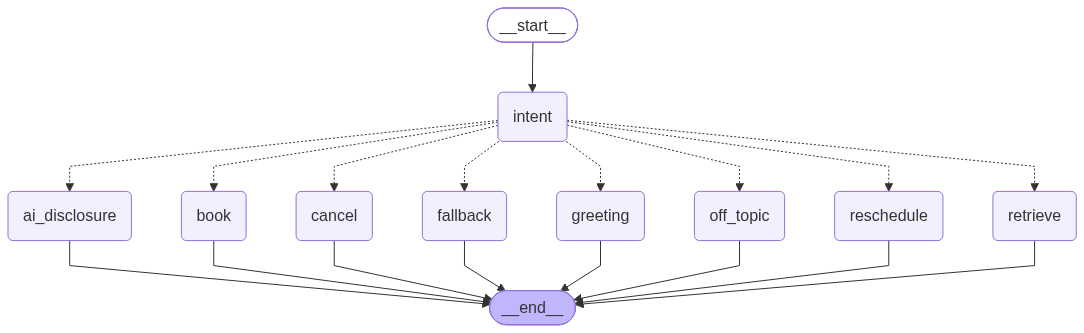

In [65]:
try:
    png_bytes = app.get_graph().draw_mermaid_png()
    with open("graph_diagram.png", "wb") as f:
        f.write(png_bytes)
    print("Graph saved: graph_diagram.png ✅")

    from IPython.display import Image, display
    display(Image(png_bytes))
except Exception as e:
    print(f"⚠️ PNG save failed (mermaid issue): {e}")
    print("Graph structure:")
    print(app.get_graph().draw_mermaid())

## 📊 Section 6: Task 5 — State Logging

In [66]:
def run_agent(user_input, user_phone="0300-1234567", verbose=True):
    """Run the LangGraph agent and return state + trace."""
    state = initial_state(user_input, user_phone)
    result = app.invoke(state)

    if verbose:
        print(f"\n{'='*60}")
        print(f"USER: {user_input}")
        print(f"INTENT: {result.get('intent', '?')}")
        print(f"AHMED: {result.get('response', '')}")
        print(f"\nTRACE ({len(result.get('trace', []))} steps):")
        for step in result.get("trace", []):
            print(f"  → {step.get('node')} @ {step.get('timestamp', '')[:19]}")

    return result

print("run_agent() ready ✅")

run_agent() ready ✅


In [67]:
def save_trace(result, test_id):
    trace_file = "day5_execution_traces.json"
    traces = []
    if os.path.exists(trace_file):
        with open(trace_file, "r") as f:
            traces = json.load(f)
    traces.append({
        "test_id": test_id,
        "user_input": result.get("user_input"),
        "intent": result.get("intent"),
        "response": result.get("response"),
        "trace": result.get("trace", []),
    })
    with open(trace_file, "w") as f:
        json.dump(traces, f, indent=2, default=str)

print("save_trace() ready ✅")

save_trace() ready ✅


## 🧪 Section 7: End-to-End Tests

In [68]:
r1 = run_agent("Mujhe Lahore mein 5 marla house chahiye budget 3 crore")
save_trace(r1, 1)


USER: Mujhe Lahore mein 5 marla house chahiye budget 3 crore
INTENT: retrieve
AHMED: Ji sir, ye options available hain: ONE BED LUXURIOUS FURNISHED APARTMENT FOR SALE AT BAHRIA TOWN LAHORE in Lahore — PKR 45 Lakh | A Beautiful Dream House Hot Location Brand New House in Lahore — PKR 57 Lakh. Kya aap visit karna chahenge?

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:50
  → retrieve @ 2026-09-25T14:17:50


In [69]:
r2 = run_agent("Mujhe visit book karni hai kal ke liye")
save_trace(r2, 2)


USER: Mujhe visit book karni hai kal ke liye
INTENT: book
AHMED: Ji sir, Saturday 03:00 PM ka visit confirm ho gaya. Aap ko email aa jaye gi.

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:50
  → book @ 2026-09-25T14:17:53


In [70]:
r3 = run_agent("Aap AI ho ya insaan?")
save_trace(r3, 3)


USER: Aap AI ho ya insaan?
INTENT: ai_disclosure
AHMED: Ji sir, main ek AI assistant hoon jo RealEstate Hub ki taraf se help kar raha hoon. Kaunsi property dekhni hai?

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:53
  → ai_disclosure @ 2026-09-25T14:17:53


In [71]:
r4 = run_agent("Meri appointment reschedule karni hai")
save_trace(r4, 4)


USER: Meri appointment reschedule karni hai
INTENT: reschedule
AHMED: Ji sir, appointment reschedule ho gayi — Saturday 05:00 PM.

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:53
  → reschedule @ 2026-09-25T14:17:55


In [72]:
r5 = run_agent("Meri appointment cancel kar do")
save_trace(r5, 5)


USER: Meri appointment cancel kar do
INTENT: cancel
AHMED: Ji sir, appointment cancel kar di gayi. Koi aur cheez?

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:55
  → cancel @ 2026-09-25T14:17:56


In [73]:
r6 = run_agent("Cricket match dekha kal?")
save_trace(r6, 6)


USER: Cricket match dekha kal?
INTENT: off_topic
AHMED: Ji sir, main yahan property search mein help ke liye hoon. Bataiye kaunsi property dekhni hai?

TRACE (2 steps):
  → intent @ 2026-09-25T14:17:56
  → off_topic @ 2026-09-25T14:17:56


## 📁 Section 8: Summary + Save


In [74]:
test_results = [
    {"test_id": 1, "input": r1["user_input"][:40], "intent": r1["intent"], "response": r1["response"][:60], "steps": len(r1.get("trace", []))},
    {"test_id": 2, "input": r2["user_input"][:40], "intent": r2["intent"], "response": r2["response"][:60], "steps": len(r2.get("trace", []))},
    {"test_id": 3, "input": r3["user_input"][:40], "intent": r3["intent"], "response": r3["response"][:60], "steps": len(r3.get("trace", []))},
    {"test_id": 4, "input": r4["user_input"][:40], "intent": r4["intent"], "response": r4["response"][:60], "steps": len(r4.get("trace", []))},
    {"test_id": 5, "input": r5["user_input"][:40], "intent": r5["intent"], "response": r5["response"][:60], "steps": len(r5.get("trace", []))},
    {"test_id": 6, "input": r6["user_input"][:40], "intent": r6["intent"], "response": r6["response"][:60], "steps": len(r6.get("trace", []))},
]
df_tests = pd.DataFrame(test_results)
df_tests.to_csv("day5_test_results.csv", index=False)
display(df_tests)

,test_id,input,intent,response,steps
0,1,Mujhe Lahore mein 5 marla house chahiye,retrieve,"Ji sir, ye options available hain: ONE BED LUX...",2
1,2,Mujhe visit book karni hai kal ke liye,book,"Ji sir, Saturday 03:00 PM ka visit confirm ho ...",2
2,3,Aap AI ho ya insaan?,ai_disclosure,"Ji sir, main ek AI assistant hoon jo RealEstat...",2
3,4,Meri appointment reschedule karni hai,reschedule,"Ji sir, appointment reschedule ho gayi — Satur...",2
4,5,Meri appointment cancel kar do,cancel,"Ji sir, appointment cancel kar di gayi. Koi au...",2
5,6,Cricket match dekha kal?,off_topic,"Ji sir, main yahan property search mein help k...",2


In [75]:
summary = {
    "day": 5,
    "tasks_completed": [
        "State design (AgentState TypedDict)",
        "Graph design (9 nodes + conditional routing)",
        "Tool integration (RAG, Calendar, Email, CRM, n8n)",
        "Validation (slot + property availability)",
        "State logging (execution traces)",
    ],
    "nodes": ["intent", "greeting", "retrieve", "book", "reschedule",
              "cancel", "ai_disclosure", "off_topic", "fallback"],
    "tests_run": len(test_results),
    "traces_saved": "day5_execution_traces.json",
    "graph_saved": "graph_diagram.png",
}
with open("day5_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\n--- Day 5 COMPLETE ---")

{
  "day": 5,
  "tasks_completed": [
    "State design (AgentState TypedDict)",
    "Graph design (9 nodes + conditional routing)",
    "Tool integration (RAG, Calendar, Email, CRM, n8n)",
    "Validation (slot + property availability)",
    "State logging (execution traces)"
  ],
  "nodes": [
    "intent",
    "greeting",
    "retrieve",
    "book",
    "reschedule",
    "cancel",
    "ai_disclosure",
    "off_topic",
    "fallback"
  ],
  "tests_run": 6,
  "traces_saved": "day5_execution_traces.json",
  "graph_saved": "graph_diagram.png"
}

--- Day 5 COMPLETE ---


In [76]:
# conn.close()  # open rakho
print("Notebook done. Connection open.")

Notebook done. Connection open.
